<a href="https://colab.research.google.com/github/Aria05MC/PlayGround/blob/main/AIImageGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Setup**

In [8]:
#@title Instalation Python
!pip -q install \
    torch \
    torchvision \
    torchaudio \
    diffusers \
    transformers \
    accelerate \
    safetensors \
    sentencepiece \
    rembg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is 

In [2]:
import torch
from diffusers import DiffusionPipeline

MODEL_ID = "votepurchase/waiNSFWIllustrious_v140"

pipe = DiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
)

pipe.to("cuda")

print("Model Loaded!")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model Loaded!


In [3]:
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()
pipe.enable_model_cpu_offload()

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


# **The Program**

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['gag . she is in nightclub , the ambient is cool , warm , little dark with lights , with camera angle from front little to the right']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['gag . she is in nightclub , the ambient is cool , warm , little dark with lights , with camera angle from front little to the right']


  0%|          | 0/28 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


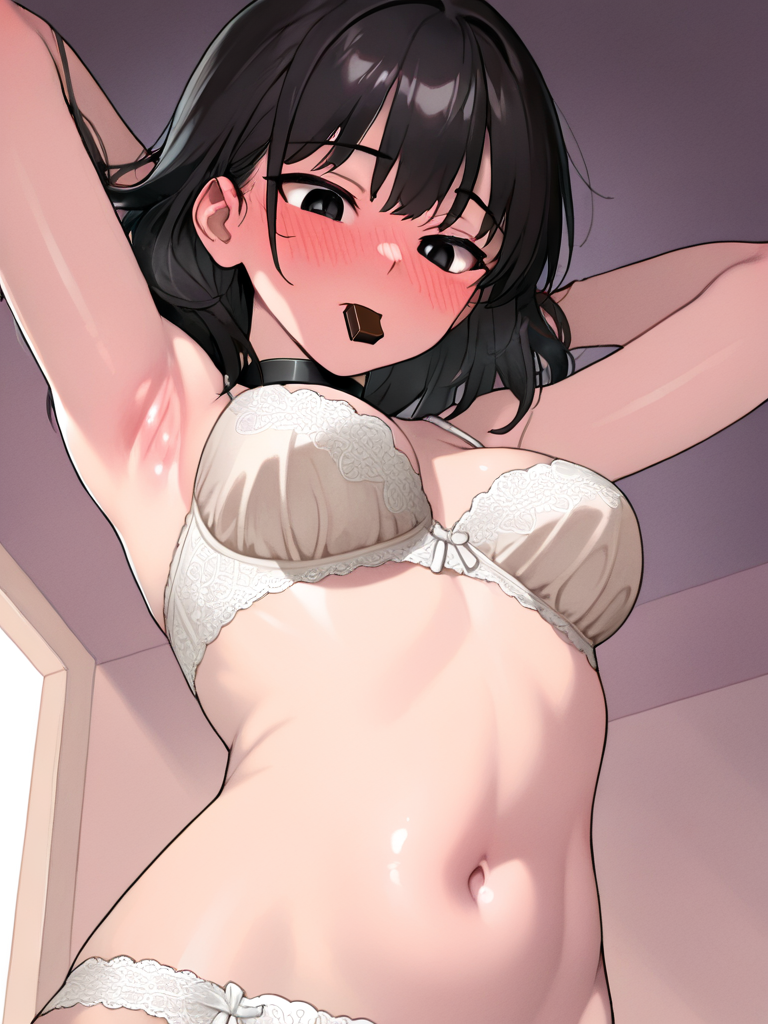

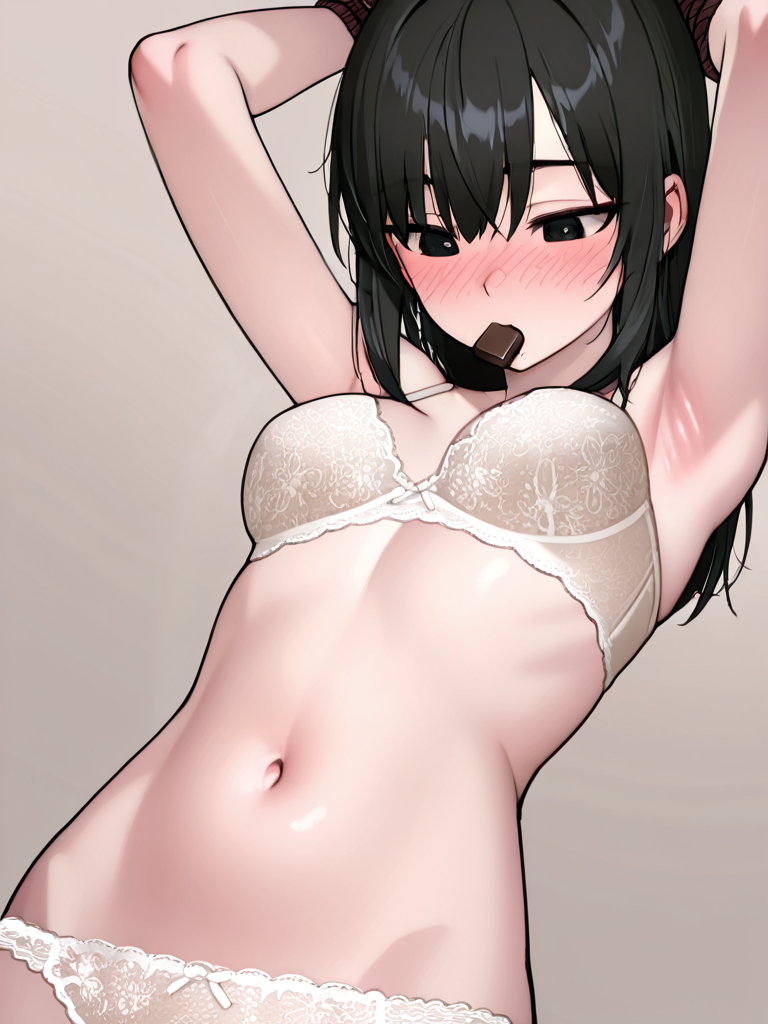

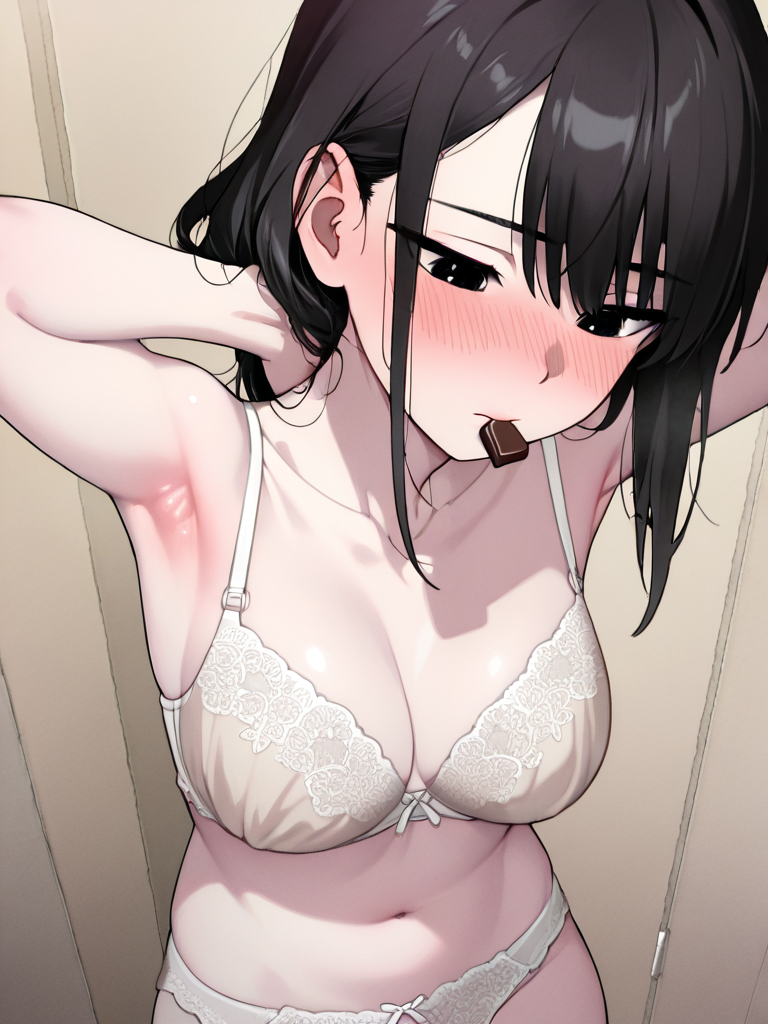

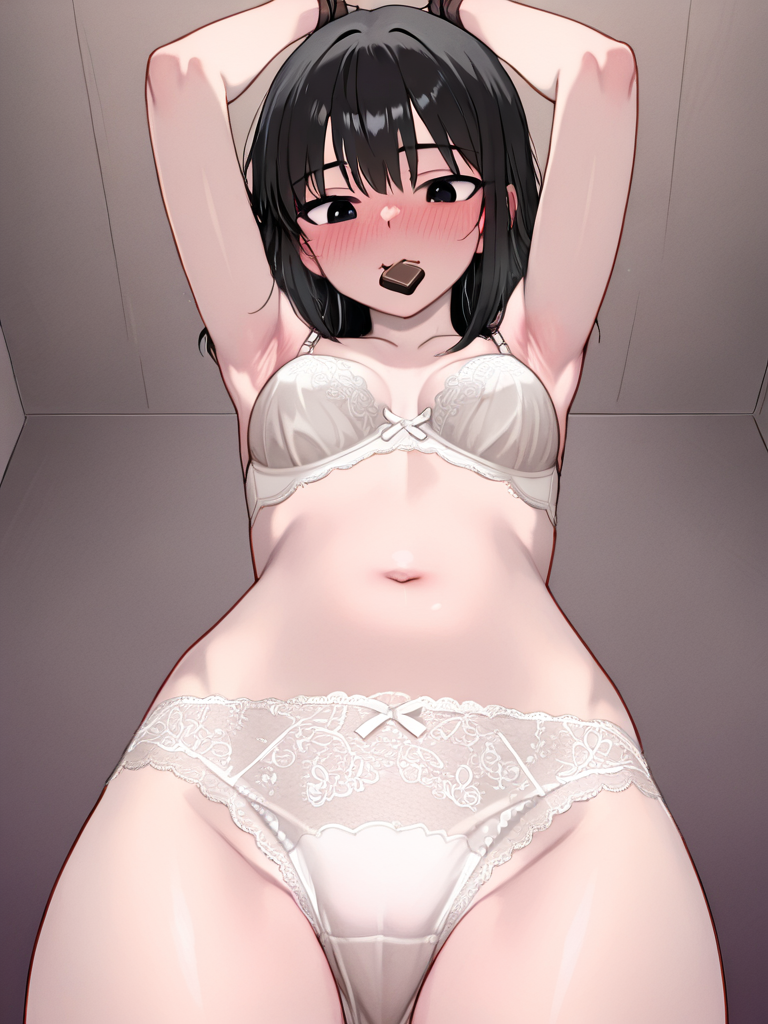

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
#@title 🎨 Image Generation Settings

prompt = "She has chocolate dark hair, fair warm beige skin, black eyes, a soft jawline, and simple cat lips. Her face is blush in shyness, she look down, try to avoiding. Her hands were tied behind her neck, making her hands rise, exposing her armpit. She only wear white lacy bra with lacy panties. Her mouth is cover with ring gag. She is in nightclub, the ambient is cool, warm, little dark with lights, with camera angle from front little to the right" #@param {type:"string"}

negative = "low quality, worst quality, blurry, bad anatomy, extra fingers" #@param {type:"string"}

width = 768 #@param {type:"integer"}
height = 1024 #@param {type:"integer"}

guidance_scale = 7.0 #@param {type:"number"}
num_inference_steps = 28 #@param {type:"integer"}

num_images = 4 #@param {type:"slider", min:1, max:10, step:1}
remove_background = "no" #@param ["no", "yes"]
#@title 🚀 Generate

from IPython.display import display
from google.colab import files
if remove_background == "yes":
    from rembg import remove

images = pipe(
    prompt=prompt,
    negative_prompt=negative,
    width=width,
    height=height,
    guidance_scale=guidance_scale,
    num_inference_steps=num_inference_steps,
    num_images_per_prompt=num_images
).images


for i, image in enumerate(images, start=1):

    if remove_background == "yes":
        image = remove(image)
        image.save(f"result_{i}.png")
    else:
        image.save(f"result_{i}.png")

    display(image)


#@title 📥 Download Options

download = "y" #@param ["y", "n"]


if download.lower() == "y":
    if len(images) == 1:
        files.download("result_1.png")
    else:
        import zipfile

        zip_name = "generated_images.zip"

        with zipfile.ZipFile(zip_name, "w") as z:
            for i in range(1, len(images)+1):
                z.write(f"result_{i}.png")

        files.download(zip_name)

In [ ]:
from google.colab import files

files.download("result.png")